<a href="https://colab.research.google.com/github/RamosTor/MineriaDeDatos/blob/main/Segundo_parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd
df = pd.read_csv('munsell-array-fixed-choice.csv')

In [ ]:
# Cuenta los colores y reinicia el índice para tener columnas 'english_color' y 'count'
english_df = df['english_color'].value_counts().reset_index()

# Divide la cuenta de cada color entre la suma total de todos los colores y multiplica por 100
english_df['en_color_percentage'] = english_df['count'] / english_df['count'].sum() * 100

# Une los dataframes solo donde los colores coinciden en ambas listas
corr_ing_esp = pd.merge(english_df, spanish_df, left_on='english_color', right_on='spanish_color', how='inner')

/tmp/ipykernel_1202/3575498959.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts.head(12), x=col, y='percentage', palette='muted')
/tmp/ipykernel_1202/3575498959.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts.head(12), x=col, y='percentage', palette='muted')
/tmp/ipykernel_1202/3575498959.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts.head(12), x=col, y='percentage', palette='muted')


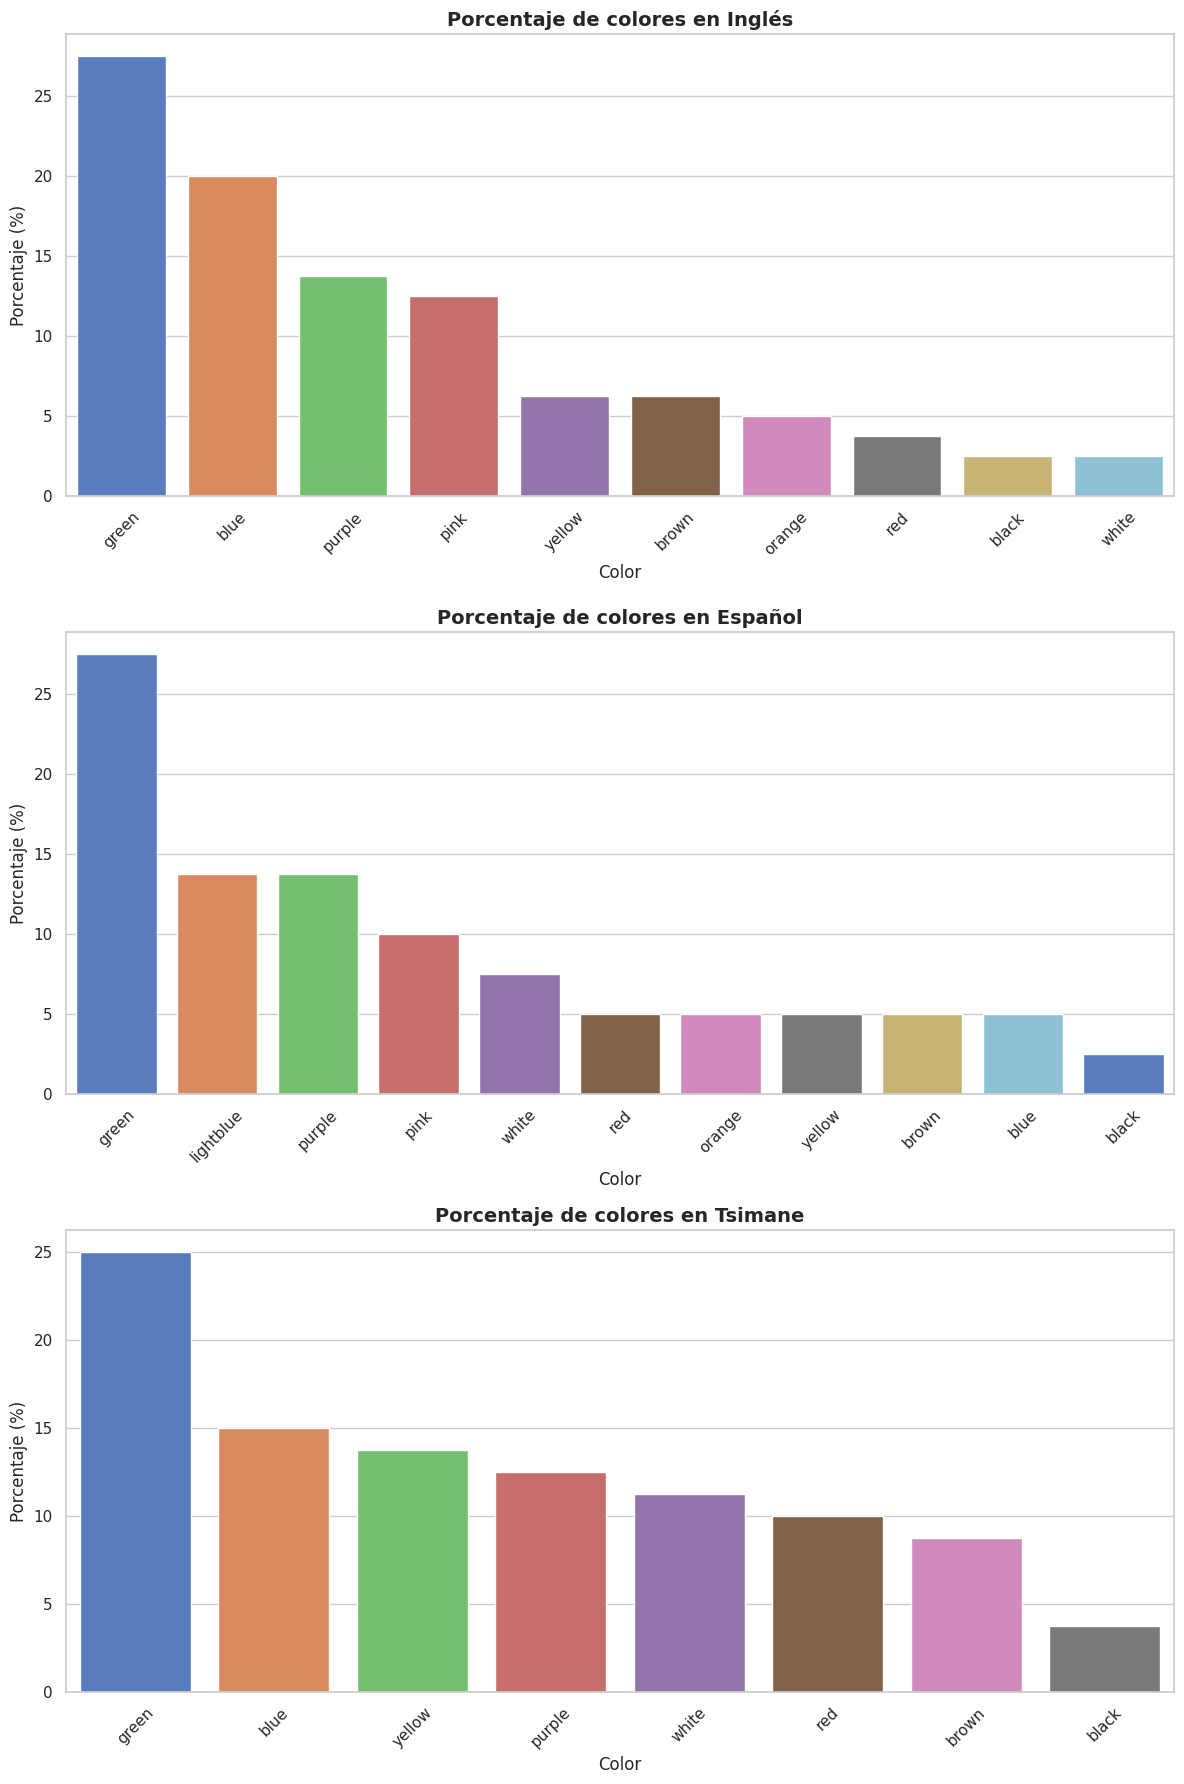

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
df = pd.read_csv('munsell-array-fixed-choice.csv')

# Definir los idiomas y sus nombres para los títulos
config = [
    ('english_color', 'Inglés'),
    ('spanish_color', 'Español'),
    ('tsimane_color', 'Tsimane')
]

# Configuración visual general
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 18))

for i, (col, idioma) in enumerate(config, 1):
    # Calcular porcentajes: (conteo / total) * 100
    counts = df[col].value_counts().reset_index()
    counts.columns = [col, 'count']
    counts['percentage'] = (counts['count'] / counts['count'].sum()) * 100

    # Crear sub-gráfica (3 filas, 1 columna)
    plt.subplot(3, 1, i)

    # Usamos barplot vertical (X=colores, Y=porcentaje)
    # Mostramos los 10 o 15 colores más frecuentes para que sea legible
    sns.barplot(data=counts.head(12), x=col, y='percentage', palette='muted')

    # Etiquetas y título
    plt.title(f'Porcentaje de colores en {idioma}', fontsize=14, fontweight='bold')
    plt.xlabel('Color', fontsize=12)
    plt.ylabel('Porcentaje (%)', fontsize=12)
    plt.xticks(rotation=45) # Rotamos los nombres para que no se encimen

plt.tight_layout()
plt.show()

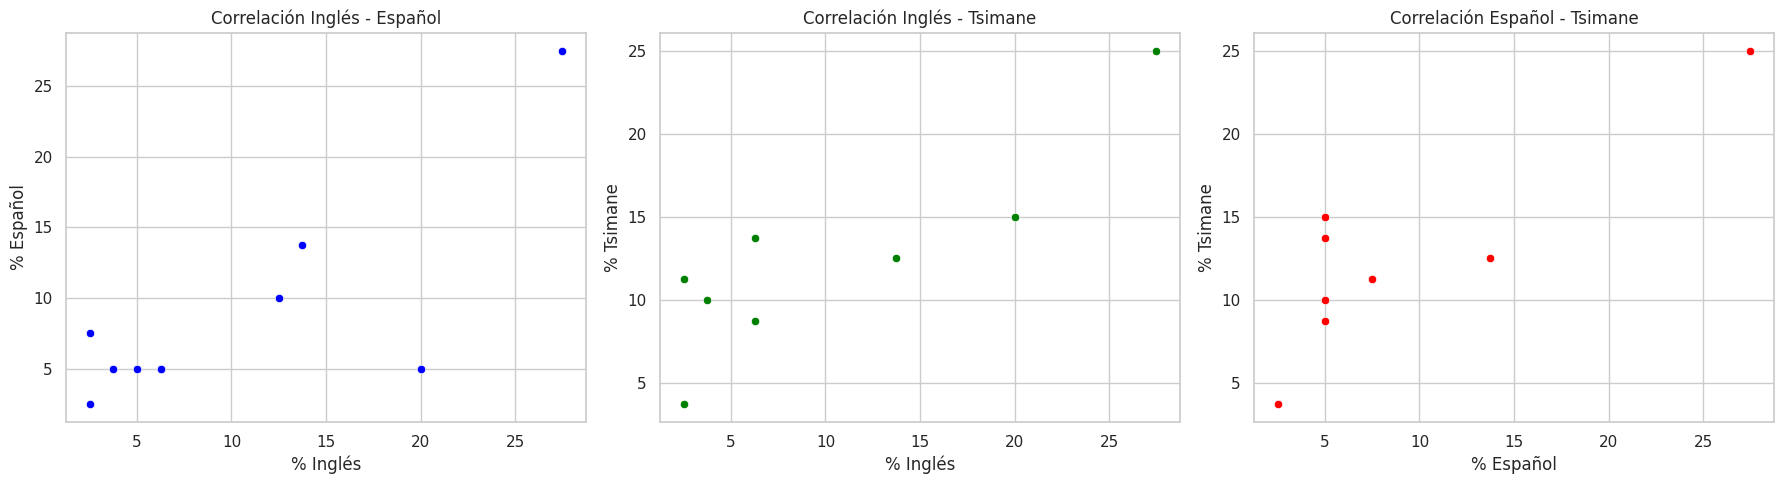

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el archivo
df = pd.read_csv('munsell-array-fixed-choice.csv')

# 2. Función para obtener conteos por idioma
def get_counts(column_name):
    counts = df[column_name].value_counts().reset_index()
    counts.columns = ['color', 'count']
    # Calculamos porcentaje para normalizar la comparación
    counts['percentage'] = (counts['count'] / counts['count'].sum()) * 100
    return counts

# Obtener datos para cada idioma
eng = get_counts('english_color')
esp = get_counts('spanish_color')
tsi = get_counts('tsimane_color')

# 3. Crear los pares de correlación uniendo las tablas
# Usamos 'inner' join para graficar solo colores que aparecen en ambos
eng_esp = pd.merge(eng, esp, on='color', suffixes=('_eng', '_esp'))
eng_tsi = pd.merge(eng, tsi, on='color', suffixes=('_eng', '_tsi'))
esp_tsi = pd.merge(esp, tsi, on='color', suffixes=('_esp', '_tsi'))

# 4. Configurar las gráficas de puntos (Scatter Plots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfica 1: Inglés vs Español
sns.scatterplot(data=eng_esp, x='percentage_eng', y='percentage_esp', ax=axes[0], color='blue')
axes[0].set_title('Correlación Inglés - Español')
axes[0].set_xlabel('% Inglés')
axes[0].set_ylabel('% Español')

# Gráfica 2: Inglés vs Tsimane
sns.scatterplot(data=eng_tsi, x='percentage_eng', y='percentage_tsi', ax=axes[1], color='green')
axes[1].set_title('Correlación Inglés - Tsimane')
axes[1].set_xlabel('% Inglés')
axes[1].set_ylabel('% Tsimane')

# Gráfica 3: Español vs Tsimane
sns.scatterplot(data=esp_tsi, x='percentage_esp', y='percentage_tsi', ax=axes[2], color='red')
axes[2].set_title('Correlación Español - Tsimane')
axes[2].set_xlabel('% Español')
axes[2].set_ylabel('% Tsimane')

plt.tight_layout()
plt.show()